In [107]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Semaine 1 : Introduction

In [108]:
G = nx.DiGraph()          # graphe orienté
G.add_nodes_from([1,2,3])
G.add_edge(1, 2)
G.add_edge(2, 3)
print(G.nodes())
print(G.edges())

[1, 2, 3]
[(1, 2), (2, 3)]


In [109]:
try:
    cycle = nx.find_cycle(G, orientation="original")
    print("Cycle trouvé:", cycle)
except nx.exception.NetworkXNoCycle:
    print("Pas de cycle")

Pas de cycle


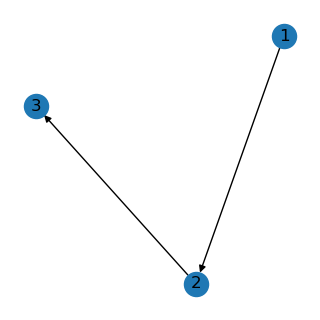

In [110]:
pos = nx.spring_layout(G, seed=0)  # placement
plt.figure(figsize=(3, 3)) 
nx.draw(G, pos, with_labels=True, arrows=True)
plt.show()

In [111]:
def make_precedence_graph(nodes, arcs):
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    G.add_edges_from(arcs)

    if not nx.is_directed_acyclic_graph(G):
        cycle = nx.find_cycle(G, orientation="original")
        raise ValueError(f"Le graphe n'est pas acyclique. Exemple de cycle: {cycle}")

    return G


In [112]:
def cocomparability_graph(G: nx.DiGraph) -> nx.Graph:
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("G doit être un DAG (graphe de précédence).")

    nodes = list(G.nodes())
    desc = {u: nx.descendants(G, u) for u in nodes}

    H = nx.Graph()
    H.add_nodes_from(nodes)

    # Ajoute {u,v} si u ne précède pas v et v ne précède pas u
    for i, u in enumerate(nodes):
        du = desc[u]
        for v in nodes[i+1:]:
            if (v not in du) and (u not in desc[v]):
                H.add_edge(u, v)
    return H


In [113]:
def draw_precedence(G):
    layers = list(nx.topological_generations(G))
    subset_dict = {k: list(layer) for k, layer in enumerate(layers)}

    pos = nx.multipartite_layout(G, subset_dict)
    plt.figure(figsize=(3, 3)) 
    nx.draw(G, pos, with_labels=True, arrows=True)
    plt.title("Graphe de précédence G")
    plt.show()


def draw_undirected(H):
    pos = nx.spring_layout(H, seed=0)
    plt.figure(figsize=(3, 3)) 
    nx.draw(H, pos, with_labels=True)
    plt.title("Graphe de co-comparabilité Hg")
    plt.show()

In [114]:
nodes = range(6)
arcs = [(0,2), (1,2), (2,3), (2,4)]  
G = make_precedence_graph(nodes, arcs)
H = cocomparability_graph(G)

print("G edges:", list(G.edges()))
print("H edges:", list(H.edges()))


G edges: [(0, 2), (1, 2), (2, 3), (2, 4)]
H edges: [(0, 1), (0, 5), (1, 5), (2, 5), (3, 4), (3, 5), (4, 5)]


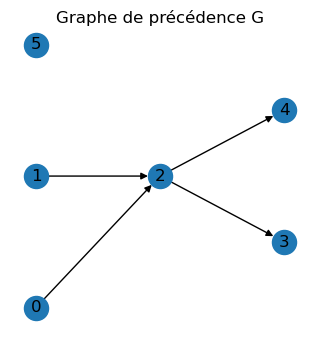

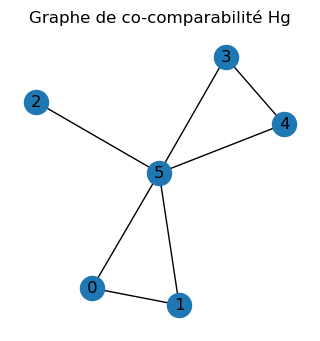

In [115]:
draw_precedence(G)
draw_undirected(H)


In [122]:
nx.core_number(H)

{0: 2, 1: 2, 2: 1, 3: 2, 4: 2, 5: 2}

# Semaine 2 : w(Hg) et k(Hg) 

In [74]:
def random_dag(n, p, seed=None):
    """
    n: nb sommets
    p: probabilité d'ajouter une arête i->j (i<j) après permutation
    """
    rng = random.Random(seed)
    order = list(range(n))
    rng.shuffle(order)
    G = nx.DiGraph()
    G.add_nodes_from(order)
    # arcs seulement "vers l'avant" => pas de cycle
    for a in range(n):
        for b in range(a+1, n):
            if rng.random() < p:
                G.add_edge(order[a], order[b])
    return G

In [99]:
def degeneracy(H: nx.Graph) -> int:
    core = nx.core_number(H)                 # node -> core number
    return max(core.values(), default=0)     # dégénérescence

def clique_number_exact(H: nx.Graph) -> int:
    """Exact, version compatible : max sur les cliques maximales énumérées."""
    return max((len(C) for C in nx.find_cliques(H)), default=0)

def clique_number_max_weight(H: nx.Graph) -> int:
    """Exact aussi (si dispo dans ta version) : clique maximum via max_weight_clique."""
    C, w = nx.algorithms.clique.max_weight_clique(H, weight=None)
    return w

{5: 7, 0: 7, 1: 6, 3: 7, 9: 7, 7: 7, 2: 7, 8: 7, 6: 7, 4: 7}


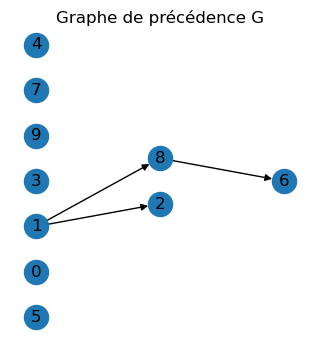

In [125]:
graphs = [random_dag(n=10, p=0.03, seed=s) for s in range(100)]
core_number = nx.core_number(cocomparability_graph(graphs[80]))
clique = nx.find_cliques(cocomparability_graph(graphs[80]))
print(core_number)
draw_precedence(graphs[80])

L'algorithme du k-coeur permet de trouver la k-dégénerescence :)  
Hg est un graphe non orienté, sa k-degenerescence correspond à prendre le plus grand k tel que k-core est non vide.


In [79]:
core_number.values()

dict_values([7, 7, 6, 7, 7, 7, 7, 7, 7, 7])

In [78]:
degeneracy = max(core_number.values(), default=0)
print(degeneracy)

7


### Efficacité des algorithmes

In [101]:
import time
def benchmark(nb_graphs=100, n=100, p=0.03, use_max_weight=True, seed0=0):
    results = []
    for s in range(seed0, seed0 + nb_graphs):
        G = random_dag(n=n, p=p, seed=s)

        # temps construction H
        t0 = time.perf_counter()
        H = cocomparability_graph(G)
        tH = time.perf_counter() - t0

        # temps clique
        t0 = time.perf_counter()
        if use_max_weight:
            try:
                w = clique_number_max_weight(H)
            except Exception:
                # fallback ultra-compatible
                w = clique_number_exact(H)
        else:
            w = clique_number_exact(H)
        tW = time.perf_counter() - t0

        # temps dégénérescence
        t0 = time.perf_counter()
        d = degeneracy(H)
        tD = time.perf_counter() - t0

        results.append({
            "seed": s,
            "|V|": H.number_of_nodes(),
            "|E(H)|": H.number_of_edges(),
            "density(H)": nx.density(H),
            "w(H)": w,
            "d(H)": d,
            "t_build_H_s": tH,
            "t_clique_s": tW,
            "t_degen_s": tD,
            "t_total_s": tH + tW + tD,
        })
    return results


In [100]:
results = benchmark(nb_graphs=100, n=100, p=0.03, use_max_weight=True)
# Affiche un résumé simple
print("Temps total moyen (s):", sum(r["t_total_s"] for r in results)/len(results))
print("Temps clique max moyen (s):", sum(r["t_clique_s"] for r in results)/len(results))
print("Dégénérescence moyenne:", sum(r["d(H)"] for r in results)/len(results))
print("Clique max moyenne:", sum(r["w(H)"] for r in results)/len(results))

Temps total moyen (s): 0.3768777959991712
Temps clique max moyen (s): 0.3614478960010456
Dégénérescence moyenne: 76.82
Clique max moyenne: 42.44


In [117]:
sum(1 for c in nx.find_cliques(H))  # The number of maximal cliques in G

3

In [121]:
[len(a) for a in nx.find_cliques(H)]

[3, 2, 3]

In [124]:
H = nx.Graph()
H.add_edges_from([(0,1),(1,2),(2,0),(2,3),(3,4),(4,5)])

print("degrees:", dict(H.degree()))
print("core_number:", nx.core_number(H))
print("degeneracy:", max(nx.core_number(H).values()))
print("2-core nodes:", sorted(nx.k_core(H, k=2).nodes()))


degrees: {0: 2, 1: 2, 2: 3, 3: 2, 4: 2, 5: 1}
core_number: {0: 2, 1: 2, 2: 2, 3: 1, 4: 1, 5: 1}
degeneracy: 2
2-core nodes: [0, 1, 2]
